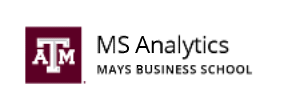

# ISTM 637 — Prediction Model Notebook
**MS Analytics · Texas A&M University · Mays Business School**

This notebook trains a model that predicts a well's **daily oil rate** from its age and
attributes, registers it in **Unity Catalog** with MLflow, and saves a **`well_forecast`
table** that your **Databricks App** reads to display each well's forward production curve.

> Prerequisite: you have already run the setup/starter notebook so the star schema
> (`fact_production`, `dim_well`, `dim_date`) exists in your catalog/schema.
> Runs on Free Edition serverless (CPU) — no GPU or model-serving endpoint required.


## 1 — Parameters

In [ ]:
NETID   = "ismithard"
CATALOG = f"istm637_{NETID}"
SCHEMA  = "oilgas"
MODEL_NAME = f"{CATALOG}.{SCHEMA}.oil_rate_predictor"   # 3-level UC name
spark.sql(f"USE CATALOG {CATALOG}"); spark.sql(f"USE SCHEMA {SCHEMA}")
print("Model will be registered as:", MODEL_NAME)

## 2 — Build the feature table from the star schema

We join the fact to both dimensions and engineer `days_online`
(`calendar_date − completion_date`). We keep producing wells and rows from completion
onward. The target is the daily `oil_bbl`.

In [ ]:
feat_df = spark.sql(f"""
  SELECT
    f.oil_bbl                                            AS target_oil_bbl,
    DATEDIFF(d.calendar_date, w.completion_date)         AS days_online,
    w.lateral_length_ft,
    w.initial_oil_potential_bopd,
    f.choke_size_64ths,
    f.tubing_pressure_psi,
    f.casing_pressure_psi,
    w.basin,
    w.target_formation,
    w.well_type
  FROM {CATALOG}.{SCHEMA}.fact_production f
  JOIN {CATALOG}.{SCHEMA}.dim_well w ON f.well_id = w.well_id
  JOIN {CATALOG}.{SCHEMA}.dim_date d ON f.date_id = d.date_id
  WHERE w.status = 'Producing'
    AND DATEDIFF(d.calendar_date, w.completion_date) >= 0
""")

pdf = feat_df.toPandas()          # ~17k rows — fits comfortably in memory
print("rows:", len(pdf))
display(feat_df.limit(5))

## 3 — Train / test split and model pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

NUM = ["days_online", "lateral_length_ft", "initial_oil_potential_bopd",
       "choke_size_64ths", "tubing_pressure_psi", "casing_pressure_psi"]
CAT = ["basin", "target_formation", "well_type"]

X = pdf[NUM + CAT]
y = pdf["target_oil_bbl"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pre = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), CAT)],
    remainder="passthrough")
model = Pipeline([("prep", pre),
                  ("reg", HistGradientBoostingRegressor(max_iter=200, random_state=42))])
model.fit(X_train, y_train)
print("trained on", len(X_train), "rows")

## 4 — Evaluate

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred = model.predict(X_test)
mae  = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
r2   = r2_score(y_test, pred)
print(f"MAE  = {mae:,.1f} bbl/day")
print(f"RMSE = {rmse:,.1f} bbl/day")
print(f"R2   = {r2:.3f}")
# TODO (extend): try adding interaction features or a different regressor and beat this R2.

## 5 — Log & register the model in Unity Catalog (MLflow)

Setting the registry to `databricks-uc` registers the model as a **governed Unity Catalog
object** — discoverable and shareable like your tables. We log a signature so the app knows
the expected input schema, then promote the version with the `@champion` alias.

> **MLflow 2 vs 3:** your notebook's *serverless environment version* determines the MLflow
> version — **version 5 ships MLflow 3.x; version 4 and earlier ship MLflow 2.x** (check the
> Environment side panel). MLflow 3 renamed `log_model(artifact_path=…)` to
> `log_model(name=…)`, so the cell below detects your version and uses the right parameter —
> it runs correctly on either environment.

> **Free Edition storage:** Free Edition uses Databricks default storage, which **denies
> MLflow's default direct-to-S3 artifact upload** for model versions (an
> `AccessDenied … explicit deny in a resource-based policy` error). The cell below sets
> `MLFLOW_USE_DATABRICKS_SDK_MODEL_ARTIFACTS_REPO_FOR_UC=True` — Databricks' documented
> fix, which uploads through the SDK instead — and includes a Volume-save safety net just
> in case.

In [ ]:
import os
# Free Edition workspaces use Databricks default storage, whose bucket policy DENIES
# MLflow's default direct-to-S3 upload of model artifacts ("AccessDenied ... explicit
# deny in a resource-based policy"). This documented switch routes the upload through
# the Databricks SDK/API instead, which is permitted:
os.environ["MLFLOW_USE_DATABRICKS_SDK_MODEL_ARTIFACTS_REPO_FOR_UC"] = "True"

import mlflow
from mlflow import MlflowClient
from mlflow.models import infer_signature

# Unity Catalog is the target registry (the default in MLflow 3; explicit for MLflow 2).
mlflow.set_registry_uri("databricks-uc")
signature = infer_signature(X_test, pred)

# MLflow 3 renamed log_model's `artifact_path=` parameter to `name=`.
# Serverless ENVIRONMENT VERSION matters here: version 5 ships MLflow 3.x,
# version 4 and earlier ship MLflow 2.x. This cell works on BOTH:
MLFLOW_3 = int(mlflow.__version__.split(".")[0]) >= 3
print("MLflow version:", mlflow.__version__, "->", "using name=" if MLFLOW_3 else "using artifact_path=")
log_kwargs = {("name" if MLFLOW_3 else "artifact_path"): "model"}

try:
    with mlflow.start_run(run_name="oil_rate_predictor") as run:
        mlflow.log_params({"max_iter": 200, "model": "HistGradientBoostingRegressor"})
        mlflow.log_metrics({"mae": mae, "rmse": rmse, "r2": r2})
        info = mlflow.sklearn.log_model(
            sk_model=model,
            signature=signature,
            input_example=X_test.head(3),
            registered_model_name=MODEL_NAME,
            **log_kwargs,
        )
    print("Registered:", MODEL_NAME, "version", info.registered_model_version)
    # Promote this version to @champion (the alias the app-side stretch goal loads)
    MlflowClient().set_registered_model_alias(MODEL_NAME, "champion", info.registered_model_version)
    print("Alias @champion ->", MODEL_NAME)
except Exception as e:
    if "AccessDenied" not in str(e) and "S3UploadFailedError" not in str(e):
        raise
    # Safety net: if this workspace still blocks model-artifact uploads, save the
    # trained pipeline to your UC Volume instead and continue with the project.
    import joblib
    fallback_path = f"/Volumes/{CATALOG}/{SCHEMA}/raw/oil_rate_predictor.joblib"
    joblib.dump(model, fallback_path)
    print("UC model registration is blocked on this workspace.")
    print(f"Saved the trained model to your Volume instead: {fallback_path}")
    print("Screenshot this file in Catalog Explorer for the Part 6 deliverable —")
    print("the well_forecast step below is unaffected and still works.")

## 6 — Forecast helper

Given a `well_id` and a horizon, we advance `days_online` forward while holding the well's
attributes and most recent operating conditions constant, then predict the daily rate.

In [ ]:
import pandas as pd

def _latest_features(well_id):
    return spark.sql(f"""
      WITH last AS (
        SELECT DATEDIFF(d.calendar_date, w.completion_date) AS days_online,
               w.lateral_length_ft, w.initial_oil_potential_bopd,
               f.choke_size_64ths, f.tubing_pressure_psi, f.casing_pressure_psi,
               w.basin, w.target_formation, w.well_type,
               ROW_NUMBER() OVER (ORDER BY d.calendar_date DESC) AS rn
        FROM {CATALOG}.{SCHEMA}.fact_production f
        JOIN {CATALOG}.{SCHEMA}.dim_well w ON f.well_id = w.well_id
        JOIN {CATALOG}.{SCHEMA}.dim_date d ON f.date_id = d.date_id
        WHERE f.well_id = '{well_id}')
      SELECT days_online, lateral_length_ft, initial_oil_potential_bopd,
             choke_size_64ths, tubing_pressure_psi, casing_pressure_psi,
             basin, target_formation, well_type
      FROM last WHERE rn = 1
    """).toPandas().iloc[0]

def forecast_well(model, well_id, horizon_days=180):
    base = _latest_features(well_id)
    rows = []
    for i in range(1, horizon_days + 1):
        r = base.copy()
        r["days_online"] = int(base["days_online"]) + i
        rows.append(r)
    fut = pd.DataFrame(rows)[NUM + CAT]
    fut_pred = model.predict(fut).clip(min=0)
    return pd.DataFrame({"day_ahead": range(1, horizon_days + 1), "predicted_oil_bbl": fut_pred})

# Demo
example_well = spark.sql(f"SELECT well_id FROM {CATALOG}.{SCHEMA}.dim_well WHERE status='Producing' LIMIT 1").collect()[0][0]
fc = forecast_well(model, example_well, 180)
print(f"180-day forecast for {example_well}: total = {fc.predicted_oil_bbl.sum():,.0f} bbl")
display(spark.createDataFrame(fc))

## 7 — Save the `well_forecast` table (this is what the App reads)

Pre-computing forecasts keeps your Part 7 app **light on compute**: the app just runs a
simple SELECT instead of loading the model. We forecast every producing well once and
save the results as a Unity Catalog table.

In [ ]:
producing = [r[0] for r in spark.sql(
    f"SELECT well_id FROM {CATALOG}.{SCHEMA}.dim_well WHERE status='Producing'").collect()]

frames = []
for w in producing:
    f = forecast_well(model, w, 180)
    f.insert(0, "well_id", w)
    frames.append(f)

all_fc = pd.concat(frames, ignore_index=True)
(spark.createDataFrame(all_fc)
      .write.mode("overwrite")
      .saveAsTable(f"{CATALOG}.{SCHEMA}.well_forecast"))
n = spark.table(f"{CATALOG}.{SCHEMA}.well_forecast").count()
print(f"well_forecast saved: {n:,} rows ({len(producing)} wells × 180 days)")

# The app's query is then simply:
#   SELECT day_ahead, predicted_oil_bbl
#   FROM {CATALOG}.{SCHEMA}.well_forecast WHERE well_id = :well
#
# Optional stretch (not required): load the registered model live in the app instead —
#   app_model = mlflow.pyfunc.load_model(f"models:/{MODEL_NAME}@champion")

---
### How this plugs into the project
- **Part 6 (this notebook):** train, evaluate, and register the model in Unity Catalog,
  then save the `well_forecast` table.
- **Part 7 (the app):** the Databricks App queries your tables for a well's production
  history and reads `well_forecast` for its forward curve — history + prediction from the
  same governed data, with minimal compute.

Commit this notebook to your GitHub repo alongside the starter notebook.
